In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 60.1 MB/s eta 0:00:00


In [ ]:
import scipy
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from statsmodels.stats.multitest import fdrcorrection
import mne
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mat_data = scipy.io.loadmat('/content/drive/MyDrive/approximate_entropy.mat')
approx = mat_data['approx']

df = pd.DataFrame(approx)

def remove_brackets(x):
    if isinstance(x, np.ndarray) and x.size == 1:
        return x.item()  # Convert single-element array to scalar
    return x

# Apply the function to all elements in the DataFrame
df = df.map(remove_brackets)

df.columns = df.iloc[0].str.replace('.set', '', regex=False)

# Remove the first row (now redundant)
df = df.iloc[1:].reset_index(drop=True)

In [ ]:
# Function to categorize column names
def categorize_column(col_name):
    condition = 'ctrl' if 'ctrl' in col_name else 'psi'
    activity = next((act for act in ['meditation', 'video', 'restingstate', 'music'] if act in col_name), 'unknown')
    return condition, activity

# Dictionary to store our new DataFrames
new_dfs = {}

# Split data into separate DataFrames
for condition in ['ctrl', 'psi']:
    for activity in ['meditation', 'video', 'restingstate', 'music']:
        # Select columns matching the current combination
        selected_columns = [col for col in df.columns if all(cat in col for cat in [condition, activity])]

        if selected_columns:
            # Create a new DataFrame with selected columns
            var_name = f"{condition}_{activity}"
            new_dfs[var_name] = df[selected_columns]
            print(f"Created DataFrame: {var_name} with {len(selected_columns)} columns")

Created DataFrame: ctrl_meditation with 60 columns
Created DataFrame: ctrl_video with 53 columns
Created DataFrame: ctrl_restingstate with 59 columns
Created DataFrame: ctrl_music with 60 columns
Created DataFrame: psi_meditation with 54 columns
Created DataFrame: psi_video with 39 columns
Created DataFrame: psi_restingstate with 52 columns
Created DataFrame: psi_music with 52 columns


In [ ]:
# Split df to control and psi
df_ctrl = df.iloc[:, 1:233]
df_psi = df.iloc[:, 233:]

def perform_comparison(df1, df2, electrodes):
    all_pval = []
    for electrode in electrodes:
        stats, pval = scipy.stats.ttest_ind(
            a=df1.loc[electrode].astype(float),
            b=df2.loc[electrode].astype(float),
            nan_policy='omit'
        )
        all_pval.append(pval)

    all_pval = pd.Series(all_pval, index=electrodes, name='p_value')
    _, fdr_results = fdrcorrection(all_pval)

    return pd.Series(fdr_results, index=electrodes, name='FDR')

# Extract electrode labels
electrodes = df['Approximate Entropy'].tolist()

# Create DataFrames for subcategories
subcategories = {}
for condition in ['ctrl', 'psi']:
    for activity in ['meditation', 'video', 'restingstate', 'music']:
        selected_columns = [col for col in df.columns if all(cat in col for cat in [condition, activity])]
        if selected_columns:
            var_name = f"{condition}_{activity}"
            subcategories[var_name] = df[selected_columns]

# Ensure all subcategories have the same index (electrodes)
for subcat in subcategories.values():
    subcat.index = electrodes

# Also ensure df_ctrl and df_psi have the correct index
df_ctrl.index = electrodes
df_psi.index = electrodes

# Perform comparisons and store results
comparisons = [
    ("Overall", df_ctrl, df_psi),
    ("Meditation", subcategories['ctrl_meditation'], subcategories['psi_meditation']),
    ("Video", subcategories['ctrl_video'], subcategories['psi_video']),
    ("Resting State", subcategories['ctrl_restingstate'], subcategories['psi_restingstate']),
    ("Music", subcategories['ctrl_music'], subcategories['psi_music'])
]

# Create the result matrix
result_matrix = pd.DataFrame(index=electrodes)
result_matrix['Electrodes'] = electrodes  # Use 'Approximate Entropy' as labels

for name, df1, df2 in comparisons:
    result_matrix[name] = perform_comparison(df1, df2, electrodes)

# Convert all columns except 'Electrodes' to float
for column in result_matrix.columns:
    if column != 'Electrodes':
        result_matrix[column] = pd.to_numeric(result_matrix[column], errors='coerce')

# Reorder columns to have 'Electrodes' as the first column
cols = ['Electrodes'] + [col for col in result_matrix.columns if col != 'Electrodes']
result_matrix = result_matrix[cols]

# Save the matrix to a CSV file
result_matrix.to_csv('fdr_comparison_matrix_preserved_order.csv', index=False)

# print(result_matrix.iloc[0:60,:].sort_values(by='Overall', ascending=True))


Opening raw data file /content/drive/MyDrive/eeg_template.fif...
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.
Reading 0 ... 0  =      0.000 ...     0.000 secs...


<ipython-input-40-534ba4ffb6e9>:28: RuntimeWarning: This filename (/content/drive/MyDrive/eeg_template.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  eeg_template = mne.io.read_raw_fif('/content/drive/MyDrive/eeg_template.fif', preload=True)


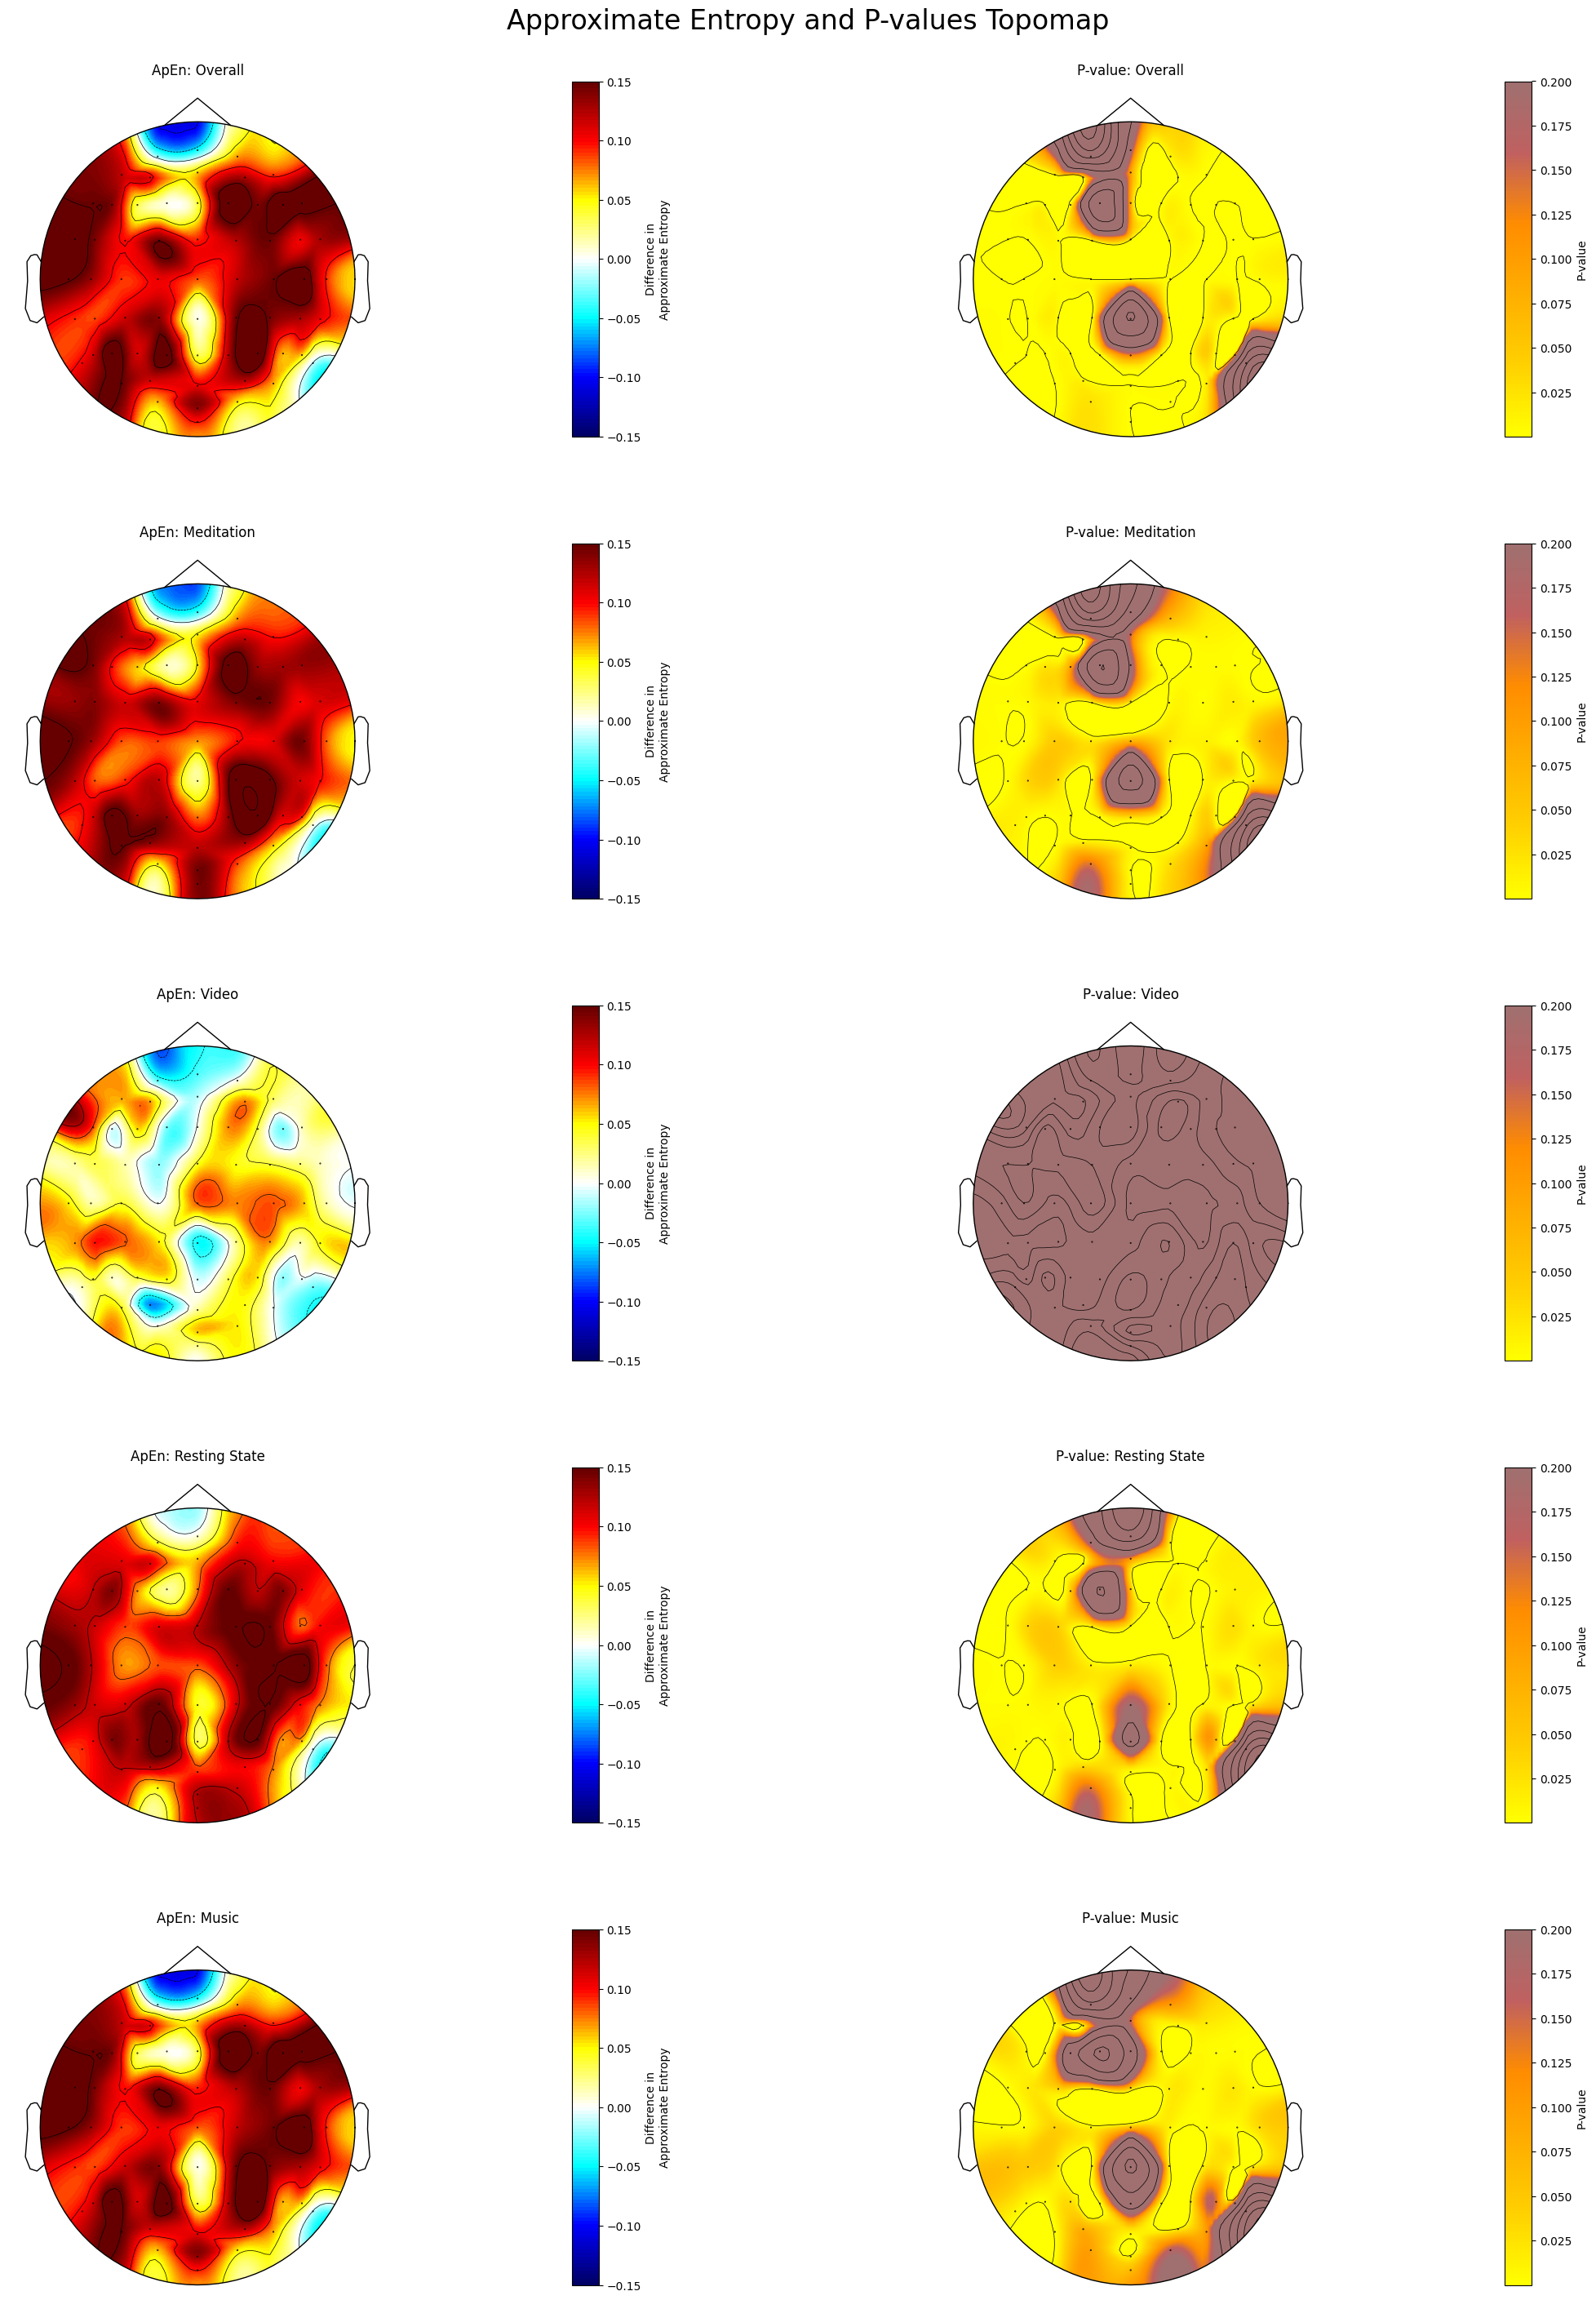

EEG channels: 64
ctrl_meditation shape: (64, 60)
ctrl_video shape: (64, 53)
ctrl_restingstate shape: (64, 59)
ctrl_music shape: (64, 60)
psi_meditation shape: (64, 54)
psi_video shape: (64, 39)
psi_restingstate shape: (64, 52)
psi_music shape: (64, 52)
P-value DataFrame shape: (64, 5)
ApEn range: -0.15 to 0.15
P-value range: 1.6982559487730573e-07 to 0.2


In [ ]:
# EEG Topomap Visualization: ApEn differences and p-values across activities


# Helper functions
def prepare_data(data):
    return data[:len(info.ch_names)]

def calculate_difference(psi_df, ctrl_df):
    return psi_df.mean(axis=1) - ctrl_df.mean(axis=1)

def prepare_pvalue_data(result_matrix):
    df = pd.DataFrame(result_matrix, columns=['Electrodes', 'Overall', 'Meditation', 'Video', 'Resting State', 'Music'])
    df.set_index('Electrodes', inplace=True)
    return df.astype(float)

def plot_topomap(data, info, ax, title, vmin, vmax, cmap):
    im, _ = mne.viz.plot_topomap(data, info, axes=ax, show=False,
                                 cmap=cmap, sensors=True, contours=6,
                                 vlim=(vmin, vmax))
    ax.set_title(title, fontsize=12)
    return im

# Load EEG template and set up montage
eeg_template = mne.io.read_raw_fif('/content/drive/MyDrive/eeg_template.fif', preload=True)
montage = mne.channels.make_standard_montage('biosemi64')
info = mne.create_info(ch_names=montage.ch_names[:64], sfreq=eeg_template.info['sfreq'], ch_types='eeg')
info.set_montage(montage)

# Prepare data
pvalue_df = prepare_pvalue_data(result_matrix)  # Ensure result_matrix is provided

# Custom colormaps
apen_cmap = LinearSegmentedColormap.from_list("custom_apen", ['#000066', '#0000FF', '#00FFFF', '#FFFFFF', '#FFFF00', '#FF0000', '#660000'], N=100)
pvalue_cmap = LinearSegmentedColormap.from_list("custom_pvalue", ['#FFFF00', '#FFD000', '#FFAE00', '#FF8C00', '#C06060', '#A07070'], N=100)

# Set up plot
fig = plt.figure(figsize=(24, 30))
gs = fig.add_gridspec(5, 6, width_ratios=[10, 0.5, 1, 10, 0.5, 1], height_ratios=[1, 1, 1, 1, 1])

activities = ['Overall', 'Meditation', 'Video', 'Resting State', 'Music']

# Calculate differences for non-overall activities
all_diffs = [calculate_difference(new_dfs[f'psi_{act.lower().replace(" ", "")}'],
                                  new_dfs[f'ctrl_{act.lower().replace(" ", "")}'])
             for act in activities[1:]]
all_diffs = [prepare_data(diff) for diff in all_diffs]

apen_vmin, apen_vmax = -0.15, 0.15
pvalue_vmin, pvalue_vmax = pvalue_df.min().min(), 0.2

# Plot topomaps
for i, activity in enumerate(activities):
    # Prepare ApEn data
    if activity == 'Overall':
        apen_data = prepare_data(diff_means.to_numpy().reshape(-1))
    else:
        psi_df = new_dfs[f'psi_{activity.lower().replace(" ", "")}']
        ctrl_df = new_dfs[f'ctrl_{activity.lower().replace(" ", "")}']
        apen_data = prepare_data(calculate_difference(psi_df, ctrl_df).to_numpy().reshape(-1))

    # Plot ApEn
    ax_apen = fig.add_subplot(gs[i, 0])
    im_apen = plot_topomap(apen_data, info, ax_apen, f'ApEn: {activity}', apen_vmin, apen_vmax, apen_cmap)
    cbar_apen = fig.colorbar(im_apen, cax=fig.add_subplot(gs[i, 1]), aspect=10)
    cbar_apen.set_label('Difference in\nApproximate Entropy', fontsize=10)

    # Plot p-values
    ax_pvalue = fig.add_subplot(gs[i, 3])
    im_pvalue = plot_topomap(pvalue_df[activity].values, info, ax_pvalue, f'P-value: {activity}', pvalue_vmin, pvalue_vmax, pvalue_cmap)
    cbar_pvalue = fig.colorbar(im_pvalue, cax=fig.add_subplot(gs[i, 4]), aspect=10)
    cbar_pvalue.set_label('P-value', fontsize=10)

# Finalize and save plot
fig.suptitle('Approximate Entropy and P-values Topomap', fontsize=24, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.95, left=0.05, right=0.95, bottom=0.05, hspace=0.3, wspace=0.5)
plt.savefig('combined_apen_pvalue_topomap_individual_colorbars.png', dpi=300, bbox_inches='tight')
plt.show()

# Debug info
print(f"EEG channels: {len(eeg_template.ch_names)}")
for key, df in new_dfs.items():
    print(f"{key} shape: {df.shape}")
print(f"P-value DataFrame shape: {pvalue_df.shape}")
print(f"ApEn range: {apen_vmin} to {apen_vmax}")
print(f"P-value range: {pvalue_vmin} to {pvalue_vmax}")